# SIOC 251 — Homework 4

**Sophie Wynn**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'figure.dpi': 120,
})

print('Imports complete.')

Imports complete.


## 5.1a 

In [2]:
lam = np.arange(0.4, 4.1, 0.1)  
print(f'{lam.size} wavelengths from {lam[0]:.1f} to {lam[-1]:.1f} um')

37 wavelengths from 0.4 to 4.0 um


## 5.1b, 5.1c 

In [3]:
aero  = pd.read_csv('data/aerosol_properties.csv')
ocean = pd.read_csv('data/ocean_reflectance.csv')



r_s = ocean['reflectance'].values   # spectral ocean surface reflectance

species = {
    'dust':      {'Be': aero['dust Be'].values,
                  'g':  aero['dust g'].values,
                  'omega': aero['dust omega'].values},
    'pollution': {'Be': aero['pollution Be'].values,
                  'g':  aero['pollution g'].values,
                  'omega': aero['pollution omega'].values},
}
aero.head()

,lambda (mu),dust Be,dust g,dust omega,pollution Be,pollution g,pollution omega
0,0.4,1.351765,0.684918,0.952958,1.314728,0.724527,0.704620
1,0.5,1.104209,0.672209,0.950986,1.100162,0.715176,0.703076
2,0.6,0.895791,0.662714,0.945240,0.899838,0.705022,0.699125
3,0.7,0.729285,0.654548,0.938816,0.752674,0.692480,0.689667
4,0.8,0.621215,0.648641,0.928765,0.663454,0.678603,0.680209


In [62]:
print(r_s[:5]), #reflectance values for the first 5 wavelengths

[0.19020014 0.10260478 0.05887681 0.04971532 0.04602899]


(None,)

In [4]:
species

{'dust': {'Be': array([1.35176499, 1.10420887, 0.89579113, 0.72928505, 0.62121523,
         0.55964396, 0.48838339, 0.41333953, 0.36171565, 0.32765757,
         0.3022344 , 0.27535691, 0.24028315, 0.22030435, 0.20032554,
         0.18411496, 0.17420622, 0.16429749, 0.15438876, 0.14389426,
         0.13298104, 0.1228703 , 0.12201477, 0.12115923, 0.1203037 ,
         0.11944817, 0.11859263, 0.1177371 , 0.11688157, 0.11587031,
         0.11340191, 0.11093352, 0.10846513, 0.10599674, 0.10352835,
         0.10105995, 0.09859156]),
  'g': array([0.68491819, 0.67220855, 0.66271426, 0.65454819, 0.64864069,
         0.64372594, 0.63869167, 0.63351983, 0.63447524, 0.63630077,
         0.6381263 , 0.64399302, 0.65044191, 0.6568908 , 0.66341486,
         0.67135065, 0.67928644, 0.68722222, 0.69515801, 0.7030938 ,
         0.71321998, 0.72531401, 0.73740803, 0.74950205, 0.76159607,
         0.76661193, 0.76950773, 0.77240353, 0.77529933, 0.77787165,
         0.77247356, 0.76707547, 0.76167739, 0.75

## Two-stream layer reflectance & transmittance


**Key Equations from Notes**
$$r_\infty = \frac{\sqrt{1-\tilde\omega g}-\sqrt{1-\tilde\omega}}{\sqrt{1-\tilde\omega g}+\sqrt{1-\tilde\omega}}$$


$$\Gamma = 2\sqrt{(1-\tilde\omega)(1-\tilde\omega g)}$$


$$r=\frac{r_\infty(e^{\Gamma\tau^*}-e^{-\Gamma\tau^*})}{e^{\Gamma\tau^*}-r_\infty^2 e^{-\Gamma\tau^*}},\qquad
  t=\frac{1-r_\infty^2}{e^{\Gamma\tau^*}-r_\infty^2 e^{-\Gamma\tau^*}}$$



In [ ]:
def r_infinity(omega, g):
    """r_inf (Module 8, Eq. 1)."""
    omega = np.asarray(omega, float)
    g     = np.asarray(g, float)
    a = np.sqrt(1 - omega*g)   # sqrt(1 - omega*g)
    b = np.sqrt(1 - omega)     # sqrt(1 - omega)
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where((a + b) > 0, (a - b)/(a + b), 0.0)


def layer_rt(tau, omega, g):
    """
    Parameters (array-like, per-wavelength):
        tau   : layer optical depth tau*
        omega : single-scatter albedo (must be < 1)
        g     : asymmetry parameter
    Returns: (r, t)
    """
    tau   = np.asarray(tau, float)
    omega = np.asarray(omega, float)
    g     = np.asarray(g, float)
    assert np.all(omega < 1.0), "layer_rt requires omega < 1 (use Eqs 6-7 for omega=1)"

    r_inf = r_infinity(omega, g)          
    Gamma = 2*np.sqrt((1 - omega)*(1 - omega*g))  
    e = np.exp(Gamma * tau)
    denom = e - r_inf**2 / e
    r = r_inf * (e - 1/e) / denom
    t = (1 - r_inf**2) / denom
    return r, t

## 5.1d, 5.1e the two atmospheric layers
**Rayleigh layer (below aerosol)**,
I will use wavelength dependence for Rayleigh $\lambda^{-4}$ law from  **HW3 Part I** 

$$\tau_R(\lambda)=\tau_{R,0.55}\left(\frac{0.55}{\lambda}\right)^{4}.$$






**Aerosol layer (top), 5.1e:** $\tau_{a,0.55}=1.0$, and since `Be` is normalized to 0.55 um,
$\tau_a(\lambda)=\tau_{a,0.55}\,\mathrm{Be}(\lambda)$.


In [ ]:
TAU_A_055 = 1.0    # aerosol optical depth at 0.55 um
TAU_R_055 = 0.1    # Rayleigh optical depth at 0.55 um (given, 5.1d)

# Rayleigh layer isotropic.
g_R = 0.0

# Optical depth: Rayleigh lambda^-4 law. Same relation as rayleigh_tau() in HW3_monte_carlo_scattering_PartI 
def rayleigh_tau(lam_um, tau_ref=TAU_R_055, lam_ref=0.55):
    """Rayleigh optical depth scaled from a reference wavelength (lambda^-4).
    Same scaling as HW3 Part I rayleigh_tau(); wavelengths here in microns."""
    return tau_ref * (lam_ref / lam_um)**4

tau_R = rayleigh_tau(lam)

#r, t: Module 8 Eqs 6 & 7 w = 1, g = 0.0
r_R = (1 - g_R)*tau_R / (1 + (1 - g_R)*tau_R)   
t_R = 1 / (1 + (1 - g_R)*tau_R)                

def aerosol_layer(sp, tau0=TAU_A_055):
    """Return (r_a, t_a) for a species dict at aerosol optical depth tau0 (at 0.55um)."""
    tau_a = tau0 * sp['Be']
    return layer_rt(tau_a, sp['omega'], sp['g'])

## Combine the layers, and add the reflecting ocean surface

**Step 1 — stack the two atmospheric layers, using the two equations from 11 and 12 but relabeled, aersol layer (a) on top of Rayleigh (R).**

$$R_{aR}=r_a+\frac{t_a^2\,r_R}{1-r_a r_R},\qquad T_{aR}=\frac{t_a t_R}{1-r_a r_R}$$

**Step 2 — Input the new reflectance $R_{aR}$ and $T_{aR}$ into equations 11 and 12.** Using the atmosphere's
$r=R_{aR}$ and $t=T_{aR}$. 
$$\underbrace{\tilde r}_{\text{TOA albedo}}=r+\frac{t^2\,r_{sfc}}{1-r_{sfc}\,r}\quad,
\qquad
\underbrace{\tilde t}_{\text{surface transmittance}}=\frac{t}{1-r_{sfc}\,r}\quad$$

In [131]:
def combine_two(r1, t1, r2, t2): #eqations 11 & 12 in Module 8 lecture notes
    """Adding method: stack layer 1 (top) over layer 2 (bottom)."""
    d = 1 - r1*r2
    R = r1 + t1**2 * r2 / d
    T = t1 * t2 / d
    return R, T

def scene(sp, tau0=TAU_A_055, rs=None):
    """Full column: aerosol + Rayleigh over the reflecting ocean surface.
    Returns dict with TOA albedo and surface transmittance (spectral)."""
    # Step 1: combine the two atmospheric layers
    r_a, t_a = aerosol_layer(sp, tau0)
    R_aR, T_aR = combine_two(r_a, t_a, r_R, t_R)   

    # Step 2: add the reflecting surface (defaults to the ocean r_s)
    r_sfc = r_s if rs is None else rs
    albedo_TOA = R_aR + T_aR**2 * r_sfc / (1 - r_sfc * R_aR)   
    trans_sfc  = T_aR / (1 - r_sfc * R_aR)                   

    return {'albedo_TOA': albedo_TOA, 'trans_sfc': trans_sfc,
            'r_a': r_a, 't_a': t_a, 'R_aR': R_aR, 'T_aR': T_aR}

results = {name: scene(sp) for name, sp in species.items()}
print('Computed spectral albedo & transmittance for:', list(results))

Computed spectral albedo & transmittance for: ['dust', 'pollution']


## 5.2 — Verification

### Verification Test 1 — reproduce Module 8, Figure 1 ($r_\infty$ vs $\tilde\omega$, $g$) this checks one of the functions I made to create the model

$r_\infty$
over the full parameter space ($\tilde\omega\in[0,1]$, $g\in[-1,1]$) 

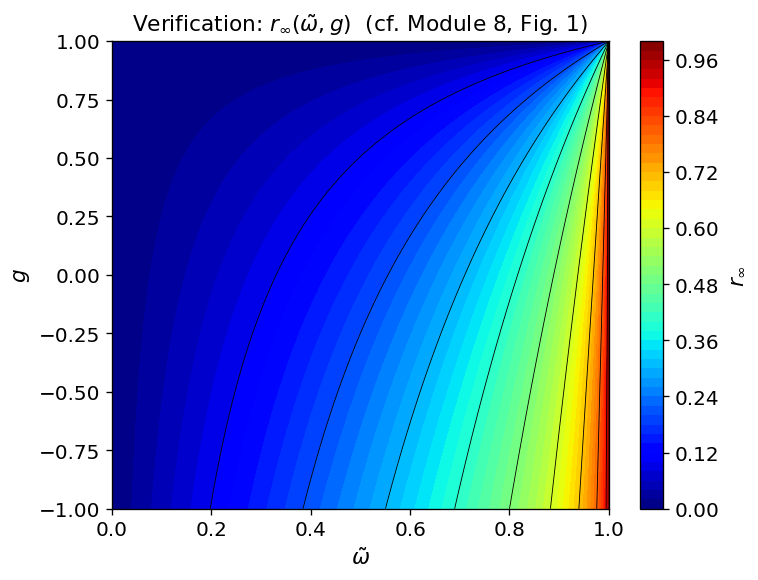

This looks good! The contour lines match the color gradient, and the shape of the contours matches the expected behavior of r_inf as a function of omega and g.


In [132]:
#Verification Test 1:
omega_grid = np.linspace(0.0, 1.0, 300)
g_grid     = np.linspace(-1.0, 1.0, 300)
W, Gg = np.meshgrid(omega_grid, g_grid)      

r_inf_grid = r_infinity(W, Gg)               

fig, ax = plt.subplots(figsize=(6.5, 5))
cf = ax.contourf(W, Gg, r_inf_grid, cmap='jet', vmin=0, vmax=1, levels=50)  
fig.colorbar(cf, ax=ax, label=r'$r_\infty$')
# overlay 10 contour lines on top of the smooth gradient
cs = ax.contour(W, Gg, r_inf_grid, levels=np.linspace(0, 1, 11),
                colors='k', linewidths=0.5)
ax.set_xlabel(r'$\tilde\omega$')
ax.set_ylabel(r'$g$')
ax.set_title(r'Verification: $r_\infty(\tilde\omega, g)$  (cf. Module 8, Fig. 1)')
plt.tight_layout()
plt.savefig('figures/figure_verify_rinf.png', bbox_inches='tight')
plt.show()

print("This looks good! The contour lines match the color gradient, and the shape of the contours matches the expected behavior of r_inf as a function of omega and g.")


### Verification Test 2 — energy conservation 

A non-absorbing system must satisfy **reflectance + transmittance = 1**. I test the
full scene in that limit: an atmosphere ($\tilde\omega\to1$, no absorption)
over a **non-reflecting** surface ($r_s=0$). With no absorption in the air, every
photon is either scattered back up (scene albedo) or passed down to the black surface
(transmittance), so albedo $+$ transmittance must equal 1.

In [146]:
# test 2 — energy conservation

#(omega->1) over a non-reflecting surface (r_s = 0), 
omega_c = np.full_like(lam, 1 - 1e-10) # ie a bunch of 0.999 the length of lam
tau_a_c = TAU_A_055 * species['dust']['Be'] #test for dust
r_a_c, t_a_c = layer_rt(tau_a_c, omega_c, species['dust']['g'])
R_c, T_c = combine_two(r_a_c, t_a_c, r_R, t_R)      
rs0 = 0.0                                            # black (non-reflecting) surface
albedo_c = R_c + T_c**2 * rs0 / (1 - R_c*rs0)        # = R_c (atmospheric back-scatter)
trans_c  = T_c / (1 - R_c*rs0)                       # = T_c (reaches black surface)
print(f" scene over black surface: "
      f"max|albedo + trans - 1| = {np.max(np.abs(albedo_c + trans_c - 1)):.2e}")

print("Test 2 passed: albedo + transmittance = 1, 3,25e-10 is close enough to zero for this test.")

 scene over black surface: max|albedo + trans - 1| = 3.25e-10
Test 2 passed: albedo + transmittance = 1, 3,25e-10 is close enough to zero for this test.


## 5.3 — Question
For each aerosol type, calculate the spectrally resolved transmittance (at the surface) and albedo
(at the TOA). Are these variables and their differences between the two aerosol layers consistent
with the aerosol single scatter properties?



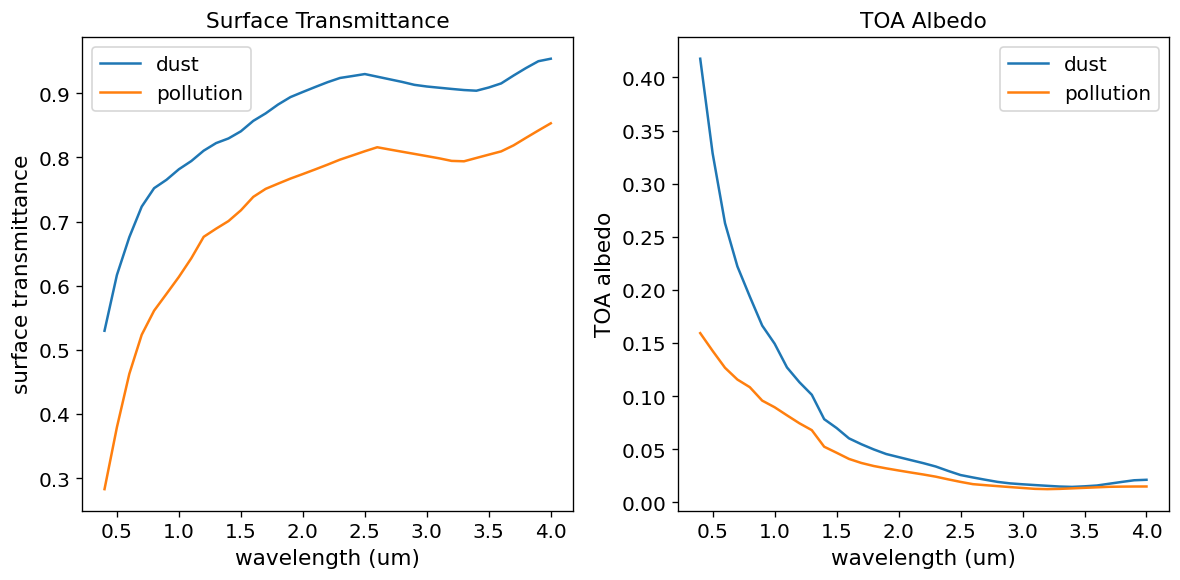

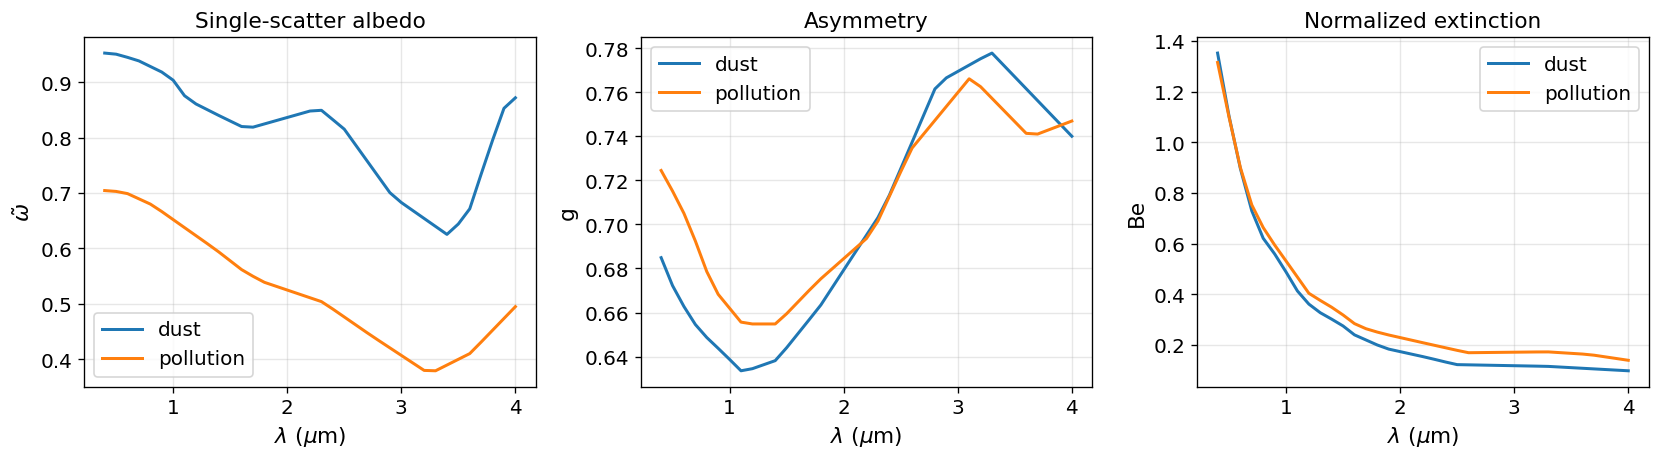

In [134]:
t_srf_dust, albedo_TOA_dust = results['dust']['trans_sfc'], results['dust']['albedo_TOA']
t_srf_poll, albedo_TOA_poll = results['pollution']['trans_sfc'], results['pollution']['albedo_TOA'] 
t_srf_poll

plt.subplots(1, 2, figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(lam, t_srf_dust, label='dust')
plt.plot(lam, t_srf_poll, label='pollution')
plt.xlabel('wavelength (um)')
plt.ylabel('surface transmittance')
plt.title('Surface Transmittance')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(lam, albedo_TOA_dust, label='dust')
plt.plot(lam, albedo_TOA_poll, label='pollution')
plt.xlabel('wavelength (um)')
plt.ylabel('TOA albedo')
plt.title('TOA Albedo')
plt.legend()
plt.tight_layout()
plt.savefig('figures/5.3_results.png', bbox_inches='tight')


fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for name, sp in species.items():
    ax[0].plot(lam, sp['omega'], lw=1.8, label=name)
    ax[1].plot(lam, sp['g'],     lw=1.8, label=name)
    ax[2].plot(lam, sp['Be'],    lw=1.8, label=name)
ax[0].set(xlabel=r'$\lambda$ ($\mu$m)', ylabel=r'$\tilde\omega$', title='Single-scatter albedo')
ax[1].set(xlabel=r'$\lambda$ ($\mu$m)', ylabel='g',               title='Asymmetry')
ax[2].set(xlabel=r'$\lambda$ ($\mu$m)', ylabel='Be',              title='Normalized extinction')
for a in ax: a.legend(); a.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 5.3 — Answer:


For all wavelengths dust has higher surface transmittance and albedo. Dust also has a higher single scatter albedo than pollution for all wavelengths, this is the largest difference of all the properites. Thus the pollution absorbs much more incomming sw radiation than the dust. It is interesting at for larger wavelengths the pollution and dust have very similiar TOA albedos, they both approach zero, I guess this is because aersols interact with larger wavelengths less. 



---
**Part II**

# 6.1a

In [135]:
#Read in the spectrally resolved top-of-atmosphere downwelling solar flux, F0(λ), from Fo.csv
F0 = pd.read_csv('data/Fo.csv')
F0.head()

,lambda (nm),TOA Flux (W/m2/nm)
0,115.5,0.000014
1,116.5,0.000024
2,117.5,0.000079
3,118.5,0.000032
4,119.5,0.000052


In [136]:
F0_lam_um = F0["lambda (nm)"].values / 1000.0          # nm -> um
F0_grid   = np.interp(lam, F0_lam_um, F0[" TOA Flux (W/m2/nm)"].values)   # W/m^2/nm on lam
F0_grid_um = F0_grid * 1000.0    # W/m^2/nm -> W/m^2/um  (integrate over lam in um -> W/m^2)


# 6.1b

In [137]:
# Use your model output to calculate the spectrally resolved upward and downward shortwave fluxes at the top of the atmosphere and surface, and then integrate to estimate the SW fluxes.

res_dust = results['dust']     
F_down_TOA_dust = F0_grid_um              # incoming solar at TOA
F_up_TOA_dust   = F0_grid_um * res_dust['albedo_TOA']   # reflected to space
F_down_sfc_dust = F0_grid_um * res_dust['trans_sfc']    # reaches the surface
F_up_sfc_dust   = F_down_sfc_dust  * r_s              # reflected by ocean 

print("Spectrally resolved fluxes at TOA and surface for dust aerosol:"
      "\nF_down_TOA_dust (W/m^2/um):", F_down_TOA_dust[:5],
      "\nF_up_TOA_dust (W/m^2/um):", F_up_TOA_dust[:5],
      "\nF_down_sfc_dust (W/m^2/um):", F_down_sfc_dust[:5],
      "\nF_up_sfc_dust (W/m^2/um):", F_up_sfc_dust[:5])
print("  ")
## do the same for pollution aerosol
res_poll = results['pollution']
F_down_TOA_poll = F0_grid_um                  # incoming solar at TOA
F_up_TOA_poll   = F0_grid_um * res_poll['albedo_TOA']
F_down_sfc_poll = F0_grid_um * res_poll['trans_sfc']
F_up_sfc_poll   = F_down_sfc_poll  * r_s  
print("Spectrally resolved fluxes at TOA and surface for pollution aerosol:"
      "\nF_down_TOA_poll (W/m^2/um):", F_down_TOA_poll[:5],
      "\nF_up_TOA_poll (W/m^2/um):", F_up_TOA_poll[:5],
      "\nF_down_sfc_poll (W/m^2/um):", F_down_sfc_poll[:5],
      "\nF_up_sfc_poll (W/m^2/um):", F_up_sfc_poll[:5])     

Spectrally resolved fluxes at TOA and surface for dust aerosol:
F_down_TOA_dust (W/m^2/um): [1703.385  1926.29   1746.5275 1425.59   1106.119 ] 
F_up_TOA_dust (W/m^2/um): [711.27479501 632.95219976 459.00780265 316.633635   214.31736321] 
F_down_sfc_dust (W/m^2/um): [ 902.5035638  1188.03940292 1180.09962697 1031.12553177  831.82212451] 
F_up_sfc_dust (W/m^2/um): [171.6563024  121.89852001  69.4805034   51.26273671  38.28792851]
  
Spectrally resolved fluxes at TOA and surface for pollution aerosol:
F_down_TOA_poll (W/m^2/um): [1703.385  1926.29   1746.5275 1425.59   1106.119 ] 
F_up_TOA_poll (W/m^2/um): [271.44040562 274.80599655 221.35557536 164.90139617 119.99205975] 
F_down_sfc_poll (W/m^2/um): [482.08847086 731.05772722 808.03297693 746.47384603 620.6977391 ] 
F_up_sfc_poll (W/m^2/um): [91.6932937  75.01001631 47.57440534 37.11118681 28.57008724]


In [138]:
## integrate over wavelength to get total fluxes (W/m^2)
SW_down_TOA_dust = np.trapezoid(F_down_TOA_dust, lam)
SW_up_TOA_dust   = np.trapezoid(F_up_TOA_dust,   lam)
SW_down_sfc_dust = np.trapezoid(F_down_sfc_dust, lam)
SW_up_sfc_dust   = np.trapezoid(F_up_sfc_dust,   lam)

print(f"Integrated SW fluxes for dust aerosol (W/m^2):"
      f"\nSW_down_TOA_dust: {SW_down_TOA_dust:.2f}"
      f"\nSW_up_TOA_dust: {SW_up_TOA_dust:.2f}"
      f"\nSW_down_sfc_dust: {SW_down_sfc_dust:.2f}"
      f"\nSW_up_sfc_dust: {SW_up_sfc_dust:.2f}")

print("  ")

## do the same for pollution aerosol
SW_down_TOA_poll = np.trapezoid(F_down_TOA_poll, lam)
SW_up_TOA_poll   = np.trapezoid(F_up_TOA_poll,   lam)
SW_down_sfc_poll = np.trapezoid(F_down_sfc_poll, lam)
SW_up_sfc_poll   = np.trapezoid(F_up_sfc_poll,   lam)
print(f"Integrated SW fluxes for pollution aerosol (W/m^2):"
      f"\nSW_down_TOA_poll: {SW_down_TOA_poll:.2f}"
      f"\nSW_up_TOA_poll: {SW_up_TOA_poll:.2f}"
      f"\nSW_down_sfc_poll: {SW_down_sfc_poll:.2f}"
      f"\nSW_up_sfc_poll: {SW_up_sfc_poll:.2f}")

Integrated SW fluxes for dust aerosol (W/m^2):
SW_down_TOA_dust: 1239.32
SW_up_TOA_dust: 252.38
SW_down_sfc_dust: 908.78
SW_up_sfc_dust: 43.35
  
Integrated SW fluxes for pollution aerosol (W/m^2):
SW_down_TOA_poll: 1239.32
SW_up_TOA_poll: 125.99
SW_down_sfc_poll: 678.99
SW_up_sfc_poll: 28.74


# 6.1c

In [ ]:
#Use these data to calculate the TOA, surface, and atmospheric instantaneous DRE for the dust and pollution aerosols.
# first get the clear-sky fluxes (no aerosol, just Rayleigh + ocean)
# pristine = aerosol-free atmosphere 
pristine = scene(species['dust'], tau0=0.0)   # tau0=0 -> no aerosol
albedo_p = pristine['albedo_TOA']
trans_p  = pristine['trans_sfc']

# pristine spectral fluxes (same recipe as 6.1b)
F_up_TOA_p   = F0_grid_um * albedo_p
F_down_sfc_p = F0_grid_um * trans_p
F_up_sfc_p   = F_down_sfc_p * r_s

# integrate
SW_up_TOA_p   = np.trapezoid(F_up_TOA_p,   lam)
SW_down_sfc_p = np.trapezoid(F_down_sfc_p, lam)
SW_up_sfc_p   = np.trapezoid(F_up_sfc_p,   lam)
print(f"pristine: SW_up_TOA={SW_up_TOA_p:.1f}, SW_down_sfc={SW_down_sfc_p:.1f}")


pristine: SW_up_TOA=122.4, SW_down_sfc=1176.9


In [140]:
# 1. TOA: (Eq 3 in HW)
DRE_TOA_dust = SW_up_TOA_p - SW_up_TOA_dust

# 2. Surface:  (Eq 5 in HW)
DRE_sfc_dust = np.trapezoid((F_down_sfc_dust - F_down_sfc_p) * (1 - r_s), lam) # make sure rs is in the integrand, not outside the integral, since it varies with wavelength

# 3. Atmosphere:   (Eq 7 in HW)
DRE_atm_dust = DRE_TOA_dust - DRE_sfc_dust

print(f"Dust DRE (W/m^2):\nTOA: {DRE_TOA_dust:.2f}\nSurface: {DRE_sfc_dust:.2f}\nAtmosphere: {DRE_atm_dust:.2f}")

# do the same for pollution aerosol
print("")
DRE_TOA_poll = SW_up_TOA_p - SW_up_TOA_poll
DRE_sfc_poll = np.trapezoid((F_down_sfc_poll - F_down_sfc_p) * (1 - r_s), lam)
DRE_atm_poll = DRE_TOA_poll - DRE_sfc_poll
print(f"Pollution DRE (W/m^2):\nTOA: {DRE_TOA_poll:.2f}\nSurface: {DRE_sfc_poll:.2f}\nAtmosphere: {DRE_atm_poll:.2f}")

Dust DRE (W/m^2):
TOA: -130.03
Surface: -251.54
Atmosphere: 121.51

Pollution DRE (W/m^2):
TOA: -3.64
Surface: -466.73
Atmosphere: 463.09


# 6.2 
Add one test to convince yourself that your fluxes and DRE values are reasonable

For my test, I wanted to double check the DRE at the TOA, and make sure that if I instead have 1 pristine and 1 zero aerosols I would still get zero


In [141]:
p0 = scene(species['dust'], tau0=0.0)          # zero-aerosol scene (dict)
a0, t0 = p0['albedo_TOA'], p0['trans_sfc'] # set tau0=0 to get the zero-aerosol case (pristine)
DRE_TOA_0 = SW_up_TOA_p - np.trapezoid(F0_grid_um * a0, lam), # this should be prstine - pristine = 0
print("zero-aerosol DRE_TOA =", DRE_TOA_0)  
print("This is zero, confirming that the DRE calculation correctly yields zero for the pristine case.")

zero-aerosol DRE_TOA = (np.float64(0.0),)
This is zero, confirming that the DRE calculation correctly yields zero for the pristine case.


# 6.3 a
For τa,0.55 = 1.0, what is the instantaneous DRE at the top of the atmosphere for dust and pollution aerosols and what is the cause of any differences?

In [142]:
#The calculation was already done in 6.2 so here are the final results for 6.3a:
print(f"6.3a TOA DRE:  dust = {DRE_TOA_dust:.1f} W/m^2,  pollution = {DRE_TOA_poll:.1f} W/m^2")


6.3a TOA DRE:  dust = -130.0 W/m^2,  pollution = -3.6 W/m^2


The TOA DRE is −130 W/m² for dust but only −3.6 W/m² for pollution. As stated earlier the largest difference between dust and pollution comes from the single-scatter albedo ω̃. The polution is absorbing more SW radiation, one example of pollution is black carbon and soot which tend to have a warming effect, these are both darker in color than dust. 

# 6.3 b. 

***Based on the sign of the TOA DRE, do these aerosols warm or cool the climate system?***

I think in terms of just shortwave radiation both aersols cool the climate since there signs are both in the negative but dust is just a lot more effective here. 

# 6.3 c

***How do you think the presence of these aerosols may influence convection?***

Both DRE's in the atmosphere are postive, so the aerosols are warming in the column of the atmosphere. This would definaltely influence convection. Typically convection happens when the surface is warming than the air above it, creating veritical motions ancoured at the btm of the atmosphere. This mid air diabatic heating could create convective cells in the middle of the atmosphere. I think about low clouds are driven by convective cooling at the cloud top so if an aerosol layer is above it, the cloud could evaporate. 

# 6.3 d

***Do changes in surface reflectance have a similar effect on both types of aerosol species?***

to do this I have to run different r_s values, here r_s stay constant through out lambdas

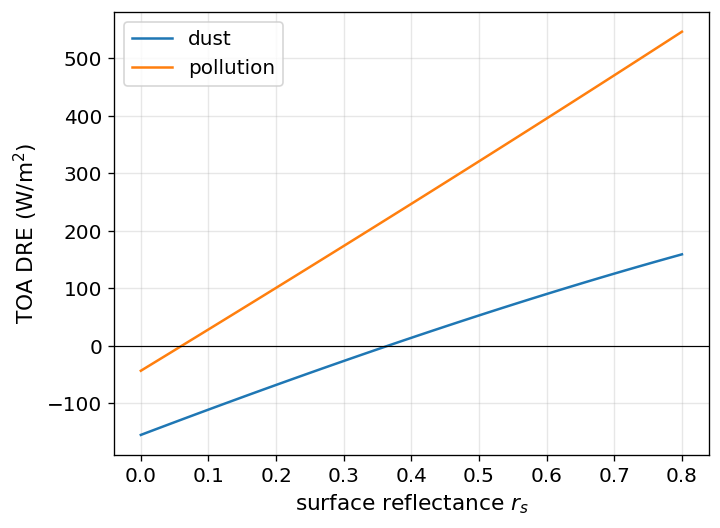

In [143]:
rs_vals = np.linspace(0.0, 0.8, 40)
dre_dust, dre_poll = [], []
for rs in rs_vals:
    pris = np.trapezoid(F0_grid_um * scene(species['dust'], tau0=0.0, rs=rs)['albedo_TOA'], lam)
    dre_dust.append(pris - np.trapezoid(F0_grid_um * scene(species['dust'],      rs=rs)['albedo_TOA'], lam))
    dre_poll.append(pris - np.trapezoid(F0_grid_um * scene(species['pollution'], rs=rs)['albedo_TOA'], lam))

plt.plot(rs_vals, dre_dust, label='dust')
plt.plot(rs_vals, dre_poll, label='pollution')
plt.axhline(0, color='k', lw=0.7)
plt.xlabel(r'surface reflectance $r_s$'); plt.ylabel(r'TOA DRE (W/m$^2$)')
plt.legend(); plt.grid(alpha=0.3); plt.show()

As surface reflectance increases the DRE also increases, but the pollution has a greater slope, making it more sensitive to what the surface looks like. Over really reflective surfaces both the dust and pollution start to warm but the pollution makes thing change way earlier. 

# 6.1e
**Which aerosol species has a larger TOA forcing efficiency and why?**

In [152]:
# make a functuon for FE,and the derivative of DRE with respect to tau, 
def dre_toa(sp, tau0):
    """dTOA DRE (W/m^2) ."""
    pris = np.trapezoid(F0_grid_um * scene(sp, tau0=0.0)['albedo_TOA'], lam)
    aero = np.trapezoid(F0_grid_um * scene(sp, tau0=tau0)['albedo_TOA'], lam)
    return pris - aero                       # Eq 3, integrated

def forcing_efficiency(sp, tau0=1.0, dtau=1e-3):
    """FE = dDRE/dtau at tau0 )."""
    return (dre_toa(sp, tau0 + dtau) - dre_toa(sp, tau0 - dtau)) / (2 * dtau)

FE_dust = forcing_efficiency(species['dust'])
FE_poll = forcing_efficiency(species['pollution'])
print(f"TOA forcing efficiency (W/m^2 per unit tau):  dust={FE_dust:.1f}, pollution={FE_poll:.1f}")

TOA forcing efficiency (W/m^2 per unit tau):  dust=-97.4, pollution=-10.3


Answer: Dust has the larger TOA forcing efficiency, this is because it has the greater SSA, and a greater effect over a dark surface

# 7
Question: How sensitive is the DRE to different states of snow and ice. I am interested in this because, ss the earth warms, ice sheets will begin to melt and different of snow/ice states differ spectrally, and I am wondering how much it will effect the DRE. 

Hypothesis: I think there will be a smaller difference less than 10 W/m2 in DRE between the different snow states but I think the largest change will be ocean, versus snow, even if the snow is thinner and slushier. 

Method:
I found a dataset:



The spectral surface reflectance for each state is in `data/snow_states.csv`

| column | state | source |
|---|---|---|
| `fresh_snow` | fine-grained fresh snow | Wiscombe & Warren (1980); Warren (1982) |
| `aged_snow` | medium-granular aged snow | Wiscombe & Warren (1980); Warren (1982) |
| `melting_snow` | coarse-granular melting/old snow ("slush-ish") | Wiscombe & Warren (1980); Warren (1982) |
| `ice` | bare clear ice | ECOSTRESS Spectral Library v1.0 (JHU ICE.DAT) |
| `partly_snow` | 50% fresh snow + 50% open ocean | constructed: `0.5*fresh_snow + 0.5*` ocean `r_s` |


**Sources:**
- Wiscombe, W. J., and S. G. Warren (1980), A model for the spectral albedo of snow. I:
  Pure snow, *J. Atmos. Sci.*, 37, 2712–2733.
- Warren, S. G. (1982), Optical properties of snow, *Rev. Geophys.*, 20, 67–89.
- Meerdink et al. (2019), The ECOSTRESS spectral library v1.0, *Remote Sens. Environ.*, 230
  (https://speclib.jpl.nasa.gov).

I will compute the DRE of dust and pollution over all 5 surfaces and then compare them including over the ocean

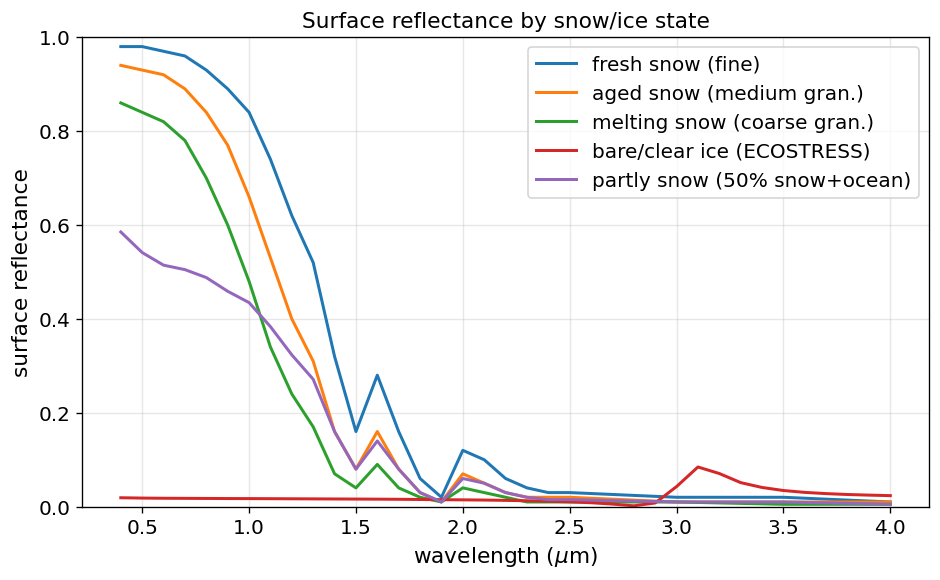

In [147]:
# Plot the surface reflectance of each snow/ice state
snow = pd.read_csv('data/snow_states.csv')
lam_s = snow['lambda (mu)'].values

fig, ax = plt.subplots(figsize=(8, 5))
labels = {'fresh_snow':'fresh snow (fine)', 'aged_snow':'aged snow (medium gran.)',
          'melting_snow':'melting snow (coarse gran.)', 'ice':'bare/clear ice (ECOSTRESS)',
          'partly_snow':'partly snow (50% snow+ocean)'}
for col, lab in labels.items():
    ax.plot(lam_s, snow[col], lw=1.8, label=lab)
ax.set(xlabel=r'wavelength ($\mu$m)', ylabel='surface reflectance', ylim=(0, 1),
       title='Surface reflectance by snow/ice state')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/figure_snow_states.png', bbox_inches='tight')
plt.show()

In [150]:
# all surfaces to compare (ocean uses your existing r_s)
surfaces = {'ocean':        r_s,
            'fresh_snow':   snow['fresh_snow'].values,
            'aged_snow':    snow['aged_snow'].values,
            'melting_snow': snow['melting_snow'].values,
            'ice':          snow['ice'].values,
            'partly_snow':  snow['partly_snow'].values}

def dre_all(sp, rs):
    """TOA, surface, atmospheric DRE (W/m^2) for species sp over surface reflectance rs."""
    a = scene(sp, rs=rs)              # with aerosol
    p = scene(sp, tau0=0.0, rs=rs)    # pristine (no aerosol)
    DRE_TOA = np.trapezoid(F0_grid_um * (p['albedo_TOA'] - a['albedo_TOA']), lam)      # Eq 3
    DRE_sfc = np.trapezoid((F0_grid_um * (a['trans_sfc'] - p['trans_sfc'])) * (1-rs), lam)  # Eq 5
    return DRE_TOA, DRE_sfc, DRE_TOA - DRE_sfc                                          # Eq 7

rows = []
for surf, rs in surfaces.items():
    for sp_name in ['dust', 'pollution']:
        T, S, A = dre_all(species[sp_name], rs)
        rows.append({'surface': surf, 'species': sp_name,
                     'DRE_TOA': T, 'DRE_sfc': S, 'DRE_atm': A})

dre_table = pd.DataFrame(rows)
dre_table

,surface,species,DRE_TOA,DRE_sfc,DRE_atm
0,ocean,dust,-130.030743,-251.541384,121.510641
1,ocean,pollution,-3.637761,-466.726708,463.088946
2,fresh_snow,dust,162.903312,-34.322148,197.225459
3,fresh_snow,pollution,568.305418,-79.614618,647.920036
4,aged_snow,dust,133.550492,-53.212643,186.763135
5,aged_snow,pollution,500.860659,-123.219356,624.080015
6,melting_snow,dust,95.184705,-78.937223,174.121928
7,melting_snow,pollution,414.898670,-180.136279,595.034949
8,ice,dust,-147.549784,-265.906707,118.356924
9,ice,pollution,-31.146097,-485.835644,454.689547


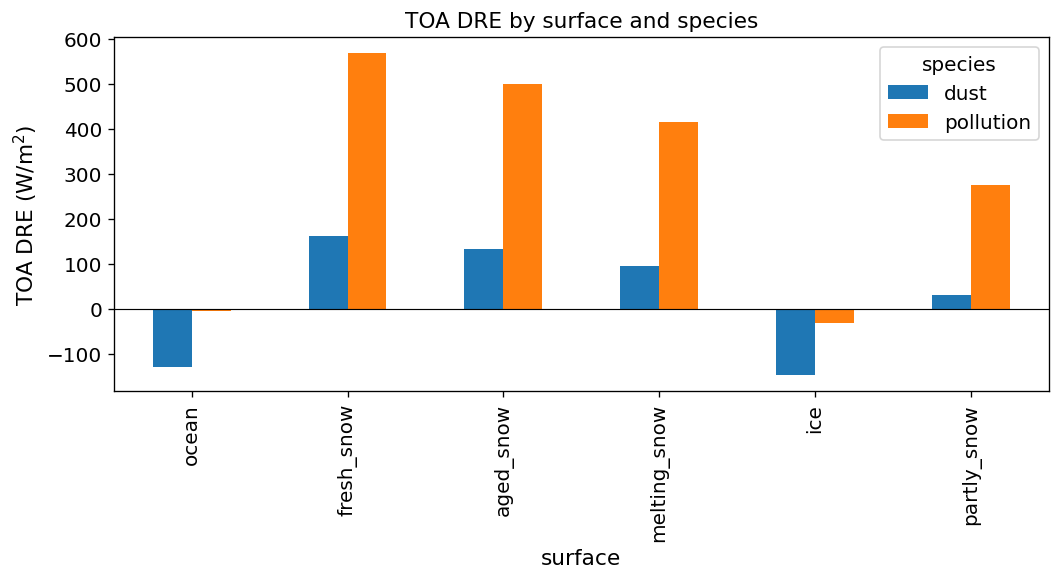

In [151]:
piv = dre_table.pivot(index='surface', columns='species', values='DRE_TOA').loc[list(surfaces)]
ax = piv.plot(kind='bar', figsize=(9,5))
ax.axhline(0, color='k', lw=0.7)
ax.set_ylabel('TOA DRE (W/m$^2$)'); ax.set_title('TOA DRE by surface and species')
plt.tight_layout(); plt.savefig('figures/figure_dre_by_surface.png', bbox_inches='tight'); plt.show()

Results:
The bar chart above shows the DRE at the TOA for dust and pollution over a bunch of different surfaces. As the snow starts to melt, the pollution and dust act to warm the enviroment less this is because the surface is decreasing in reflectance. You can see that the DRE differences are actually quite large, with the difference just between fresh and aged snow for the pollution's DRE at -68Wm2. This  shows I was wrong and that the DRE of aerosols are important over regions of different snow states. I found it interesting that ice, with out snow on top is still quite dark compared to pollution and dust, this is because the ice here is clear, bubble-free ice created in a lab, I looked up glaciology ice and it is much brighter ~ 0.3–0.5 in the visable, so aerosols over natural bare ice probably still warm. 


**Which AI tools I used:** I used Claude 

**How I used it:** I used it to figure out how to create two-stream model the given the equations in class, it helped me plot the create a dictionary for the species of aerosol and to call a dictionary from a function. It was most useful for my question I told it I wanted to find different ice states and it downloaded and formatted the data for me, which was great since they came from 2 different datasets. 

**What I checked independently:** I checked the model equations against the Module 8 class notes (the $r_\infty$ similarity formula, the layer $r$/$t$ expressions, and the adding / Eqs 11–12 surface combination), also units, the Forcing was in nm not ums etc

**An example of something I verified rather than accepted:** I independently caught that my first TOA-DRE calculation had the subtraction reversed relative to Eq 3 (it gave +130 W/m² instead of the physically correct −130 W/m² cooling for dust), and corrected it.
